# Diabetes Progression Prediction using Neural Networks

This notebook performs regression on the diabetes dataset by:
1. Loading the standard diabetes dataset from scikit-learn
2. Training a small ReLU neural network with PyTorch (MSE loss on a standardised target)
3. Visualising prediction accuracy and training progress
4. Comparing the neural network against pseudo-inverse (linear) regression

## Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

## Load the Dataset

The diabetes dataset has 442 patients described by 10 normalised physiological
features. The regression target is a quantitative measure of disease progression
one year after baseline.

In [2]:
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

# Standardise the target so the network learns a zero-mean, unit-variance signal.
y_mean = y_train_t.mean()
y_std  = y_train_t.std()
y_train_n = (y_train_t - y_mean) / y_std

train_loader = DataLoader(TensorDataset(X_train_t, y_train_n), batch_size=16, shuffle=True)

## Define the Neural Network

A single hidden layer with 32 ReLU units. With only 353 training samples,
a deeper network risks overfitting; one hidden layer is enough to learn
the non-linearities present in this dataset. The output is a single linear
unit for regression.

In [3]:
net = nn.Sequential(
    nn.Linear(X_train.shape[1], 32),
    nn.ReLU(),
    nn.Linear(32, 1),
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters())

## Train the Model

Training MSE is tracked per epoch on the standardised target. Because `y` was
scaled to unit variance, an MSE of 1.0 corresponds to "as bad as predicting the
mean" — anything below that is real signal.

In [6]:
n_epochs = 300
history_mse = []
n_train = len(X_train_t)

for epoch in range(n_epochs):
    net.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        out = net(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(y_batch)
    print(f"Epoch {epoch+1}/{n_epochs}, MSE: {epoch_loss / n_train:.4f}", end="\r")
    history_mse.append(epoch_loss / n_train)

## Results

Two plots side-by-side: predicted vs true values (a perfect model would lie on the red diagonal)
and training MSE over epochs.

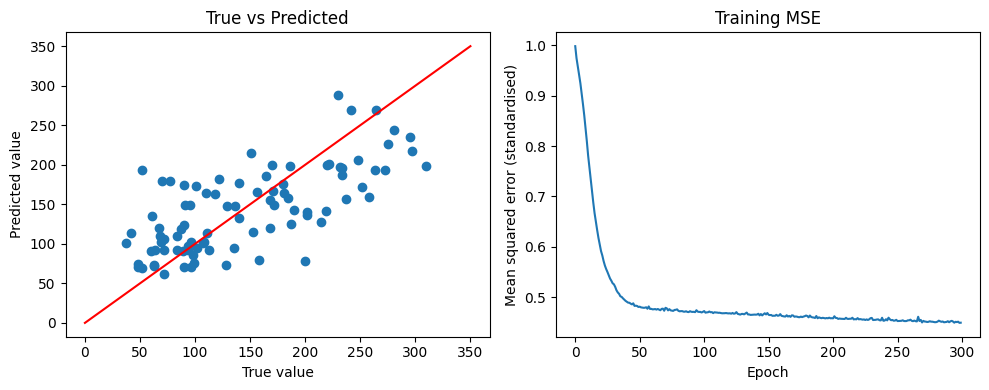

In [5]:
net.eval()
with torch.no_grad():
    # Un-standardise: network learned in normalised space, plot in original units.
    y_pred = (net(X_test_t) * y_std + y_mean).numpy()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(y_test, y_pred, 'o')
ax[0].plot([0, 350], [0, 350], 'r-')
ax[0].set_xlabel('True value')
ax[0].set_ylabel('Predicted value')
ax[0].set_title('True vs Predicted')

ax[1].plot(history_mse)
ax[1].set_title('Training MSE')
ax[1].set_ylabel('Mean squared error (standardised)')
ax[1].set_xlabel('Epoch')

plt.tight_layout()
plt.show()